# Projeto Fundamentos de Aprendizagem Automática
**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

## Problema
**Prever a nota final** com base em todas as variáveis comportamentais, exceto 


* student_id
* productivity_score  
* burnout_level 
* focus_index
    

## Variáveis-Alvo (Targets)

### Cenário de Classificação (y)

Transformar a variável _Exam Score_ em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:

Dados originais: min=1.0, max=64.09


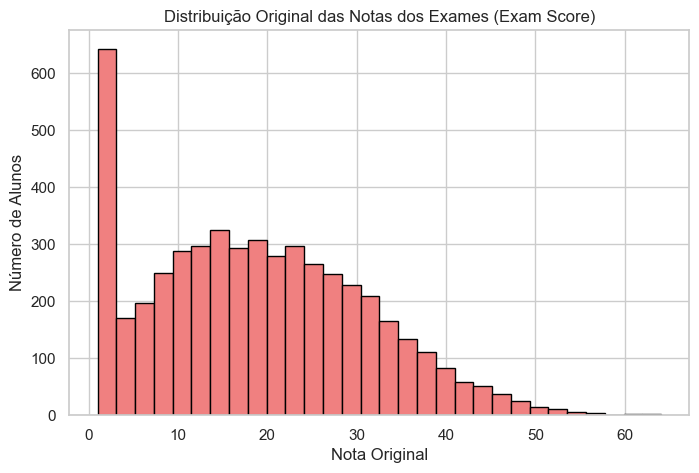

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
# Ler o arquivo CSV com os dados originais
df = pd.read_csv('student_records_missing.csv')

# Verificar o intervalo dos dados originais
print(f"Dados originais: min={df['exam_score'].min()}, max={df['exam_score'].max()}")

# Realizar a análise exploratória dos dados originais
df['exam_score'].hist(bins=30, color='lightcoral', edgecolor='black', figsize=(8,5))
plt.title("Distribuição Original das Notas dos Exames (Exam Score)")
plt.xlabel('Nota Original')
plt.ylabel('Número de Alunos')
plt.show()

## Análise da Distribuição Original e Justificação da Transformação

#### 1. Observação inicial

A partir do histograma da distribuição original do `exam_score` (apresentado acima), verificamos que os valores se encontram aproximadamente no intervalo **[0, 65]**, e não no intervalo tradicional [0, 100] que é habitualmente utilizado no contexto educacional.

#### 2. Problemas identificados

Esta escala original [0, 65] apresenta duas limitações importantes:

- **Falta de intuitividade para os stakeholders** (professores, gestores, alunos): uma nota de 30 em 65 não é imediatamente compreendida como "insuficiente" ou "suficiente" sem cálculos adicionais.

- **Dificuldade na definição de limiares claros**: num intervalo não padronizado, fica mais difícil definir um ponto de corte lógico para classificação binária (ex: reprovado/aprovado).

#### 3. Solução adotada

Para resolver estes problemas, decidimos aplicar uma **transformação linear** utilizando o `MinMaxScaler` da biblioteca `scikit-learn`, com os seguintes parâmetros



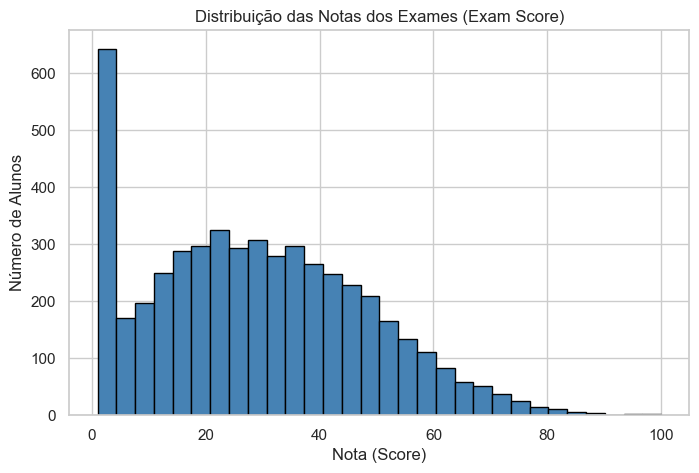

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler



# print(df["exam_score"].min(), df["exam_score"].max())


# Obter os valores de "exam_score" para a faixa de 1 a 100 usando MinMaxScaler
scaler = MinMaxScaler(feature_range=(1, 100))
df["exam_score"] = scaler.fit_transform(df[["exam_score"]])

# Realizar a análise exploratória dos dados transformados
df['exam_score'].hist(bins=30, color='steelblue', edgecolor='black', figsize=(8, 5))
plt.title('Distribuição das Notas dos Exames (Exam Score)')
plt.xlabel('Nota (Score)')
plt.ylabel('Número de Alunos')
plt.show()





**Classificação multiclass (Nota entre 0 até 100):**

|**Categoria**|**Intervalo (Exam Score)**|
|---|---|
|**Insuficiente**|0 a 39|
|**Suficiente**|40 a 100|


Com base nos dados que estão muito desbalanceado, decidimos fazer uma classificação binária, e após utilizarmos scaling para transformar o intervalo de [1, 65] em [1, 100], reparámos que a maior parte de os alunos teria chumbado se a divisão fosse efetuada exatamente a meio, para mitigar este acontecimento, consideramos Suficiente todas as notas >40.


## Stakeholders

- **Os próprios estudantes** :Beneficiariam ao compreender de forma clara como os seus hábitos de vida (como as horas de sono, tempo de ecrã e o balanço entre estudo e lazer) impactam diretamente o seu desempenho académico. Ter acesso a esta previsão permite-lhes ajustar comportamentos de forma proativa e atempada, evitando o insucesso escolar (chumbo) ou níveis extremos de exaustão (burnout).
    
- **A instituição de ensino / Escola** :Pode utilizar este modelo preditivo para identificar antecipadamente uma percentagem de alunos em risco de reprovação. Isto permite à gestão escolar uma melhor alocação de recursos pedagógicos, como a promoção de turmas de apoio extra ou a reavaliação da carga de trabalhos exigida.
    
- **Conselheiros / Tutores** :Passam a ter acesso a uma ferramenta de apoio à decisão baseada em dados reais para oferecer um acompanhamento muito mais personalizado. Em vez de conselhos genéricos, o tutor pode focar-se nas variáveis específicas que o modelo identificou como problemáticas para um determinado aluno (por exemplo, excesso de horas em videojogos ou falta de qualidade de sono).
    
- **Serviços de Apoio ao Estudante(Apoio Psicológico)** :Podem atuar de forma preventiva junto de alunos cujo perfil cruze um baixo rendimento académico com indicadores de má saúde mental (como altos níveis de ingestão de cafeína e privação de sono). O modelo serve como um sistema de alerta para oferecer suporte psicológico antes que o aluno atinja um ponto de rutura.


## 1. Pré-processamento de Dados
### 1.1 Ler ficheiros misssing e imprimir pecentagem de missing

In [153]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder



df_colunas = df.columns


# imprimir percentagem missing values por coluna
missing_percent = df.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])






--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64


### 1.2 Transforma Exam Score em(Insuficiente / Suficiente)

In [154]:
# Obter os valores de "exam_score" para a faixa de 1 a 100 usando MinMaxScaler
df_y = df["exam_score"].copy()
# print(df_y.head())




# Categorizar os valores de "exam_score" em "Insuficiente" e "Suficiente" com base no critério de corte de 40
def categorizar_exame_score(score):
    if score < 40:
        return 'Insuficiente'  
      
    else:
        return 'Suficiente'  

df_y_categorico = df_y.apply(categorizar_exame_score)

# Verificar a distribuição das categorias
print("\n=== Distribuição das Categorias ===")
print(df_y_categorico.value_counts())
print("\n=== Proporção das Categorias ===")
print(df_y_categorico.value_counts(normalize=True))


=== Distribuição das Categorias ===
exam_score
Insuficiente    3562
Suficiente      1438
Name: count, dtype: int64

=== Proporção das Categorias ===
exam_score
Insuficiente    0.7124
Suficiente      0.2876
Name: proportion, dtype: float64


### Especificação Técnica (Pré-processamento e Métricas de Avaliação)



Como demonstrado acima, os dados apresentam um desequilíbrio significativo (Insuficiente representa cerca de 71%, Suficiente cerca de 29%).
Se fosse utilizada a acurácia (Accuracy), o modelo poderia tender a prever sempre a classe maioritária, obtendo uma pontuação artificialmente elevada.
Por este motivo, este projeto adota o **F1-Score** como métrica de avaliação principal, equilibrando a precisão e a sensibilidade (recall).

### 1.3 Transforma Exam Score em binario 

In [155]:
# OrdinalEncoder (categories=categories) para transformar as categorias em números ordinais
categories = [["Insuficiente", "Suficiente",]]
oe = OrdinalEncoder(categories=categories)
df_y_categorico_ordinais = oe.fit_transform(df_y_categorico.to_frame())

# print(df_y_categorico_ordinais)

### 1.4 Definir X e fazer treino

In [156]:
# Definir Variável X

# print(df.shape)
df.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
X = df.copy()  # Variável X com as colunas restantes

# print(X.shape)


# 7. one split para separar os dados em treino e teste
X_learning, X_test, y_learning, y_test = train_test_split(
    X, df_y_categorico_ordinais, test_size=0.2, random_state=42, stratify=df_y_categorico_ordinais
)

### 1.5 Tratar Missing

In [157]:

# Separar colunas numéricas e categóricas em X_learning para preencher os valores vazios
num_cols = X_learning.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_learning.select_dtypes(include=['object', 'string']).columns.tolist()

# Calcular a mediana para as colunas numéricas e a moda para as colunas categóricas em X_learning
medians = X_learning[num_cols].median()
modes = X_learning[cat_cols].mode().iloc[0]

# print("\n Medianas para colunas numéricas:")
# print(medians)

# print("\n Modas para colunas categóricas:")
# print(modes)



# Preencher os valores vazios em X_learning com as medianas e modas calculadas
X_learning[num_cols] = X_learning[num_cols].fillna(medians)
X_learning[cat_cols] = X_learning[cat_cols].fillna(modes)

# Preencher os valores vazios em X_test com as mesmas medianas e modas calculadas a partir de X_learning
X_test[num_cols] = X_test[num_cols].fillna(medians)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)




print("\n Total atual de valores vazios :", X_learning.isnull().sum().sum() + X_test.isnull().sum().sum())
# print(X_learning.head())
# print(X_test.head())





 Total atual de valores vazios : 0


### 1.6 One-Hot Encoding para X_learning e X_test

In [158]:
# Utilizando(One-Hot Encoding) para transformar as colunas categóricas em variáveis dummy
X_learning = pd.get_dummies(X_learning, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
# print(X_learning.head())


### Justificações Técnicas (Pré-processamento e Métricas)

* **Codificação (Encoding):** Optou-se pelo `One-Hot Encoding` para variáveis categóricas nominais, pois não existe uma relação de ordem inerente entre as categorias. Para variáveis com ordem lógica (se existirem), seria utilizado o `Ordinal Encoding`.
* **Escalonamento (Scaling):** Utilizou-se o `StandardScaler` porque modelos baseados em distância (como KNN) e algoritmos de otimização (como Redes Neuronais) são altamente sensíveis à magnitude dos dados. O StandardScaler assume que os dados têm distribuição normal e foca-os em torno de 0 com desvio padrão de 1.
* **Métricas de Sucesso:**
    * **Métrica Primária:** `F1-Score` (Binary). Como estamos perante um problema de classificação binária (onde o foco é prever corretamente os casos positivos, ex: reprovação/risco), o F1-Score oferece um equilíbrio crucial entre Precision e Recall, sendo mais robusto que a exatidão (Accuracy) em casos de ligeiro desequilíbrio de classes.
    * **Métrica Secundária:** `ROC-AUC` e `Accuracy`. O ROC-AUC ajuda a avaliar a capacidade do modelo em distinguir entre as duas classes, independentemente do limiar (threshold) de decisão.

## 2. Seleção de Atributos
### 2.1 Variance-based feature selection

In [159]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

#实例化选择器，设置方差阈值为 0.01。
selector_var = VarianceThreshold(threshold=0.01) 
X_learning_var = selector_var.fit_transform(X_learning)
X_test_var = selector_var.transform(X_test)

# 获取保留的特征
selected_var_features = X_learning.columns[selector_var.get_support()]

var_features_removed = []  # 创建一个空列表
for col in X_learning.columns:      # 遍历每一个特征名
    if col not in selected_var_features:   # 如果这个特征不在"被选中的特征列表"里
        var_features_removed.append(col)   # 就把它加入"被移除的特征列表"

        
print(f"Original shape: {X_learning.shape[1]}")
print(f"Reduced shape after variance threshold: {X_learning_var.shape[1]}")
print(f"Features removed: {X_learning.shape[1] - X_learning_var.shape[1]}")
print(f"Selected features: {list(selected_var_features)}")
print(f"Features removed: {var_features_removed}")
selected_var_features

# normalizing data
scaler = StandardScaler()
X_learning_var_scaled = scaler.fit_transform(X_learning_var)
X_test_var_scaled = scaler.transform(X_test_var)







Original shape: 22
Reduced shape after variance threshold: 22
Features removed: 0
Selected features: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'gender_Female', 'gender_Male', 'gender_Other', 'academic_level_High School', 'academic_level_Postgraduate', 'academic_level_Undergraduate', 'internet_quality_Average', 'internet_quality_Good', 'internet_quality_Poor']
Features removed: []


### 2.2 Correlation-based feature selection

In [160]:
import numpy as np
#计算训练集特征之间的 Pearson 相关系数矩阵，并取绝对值。
corr_matrix = X_learning.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 找出高度相关的特征对
corr_threshold = 0.9  # 可以调整
to_drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print(f"Original number of features: {X_learning.shape[1]}")
print(f"Number of features to drop: {len(to_drop_corr)}")
print("Features to drop:")
to_drop_corr


# 移除高度相关的特征
X_learning_corr = X_learning.drop(columns=to_drop_corr)
X_test_corr = X_test.drop(columns=to_drop_corr)
# print(f"保留特征数: {X_learning_corr.shape[1]}")

# 标准化并训练模型
scaler = StandardScaler()
X_learning_corr_scaled = scaler.fit_transform(X_learning_corr)
X_test_corr_scaled = scaler.transform(X_test_corr)





Original number of features: 22
Number of features to drop: 0
Features to drop:


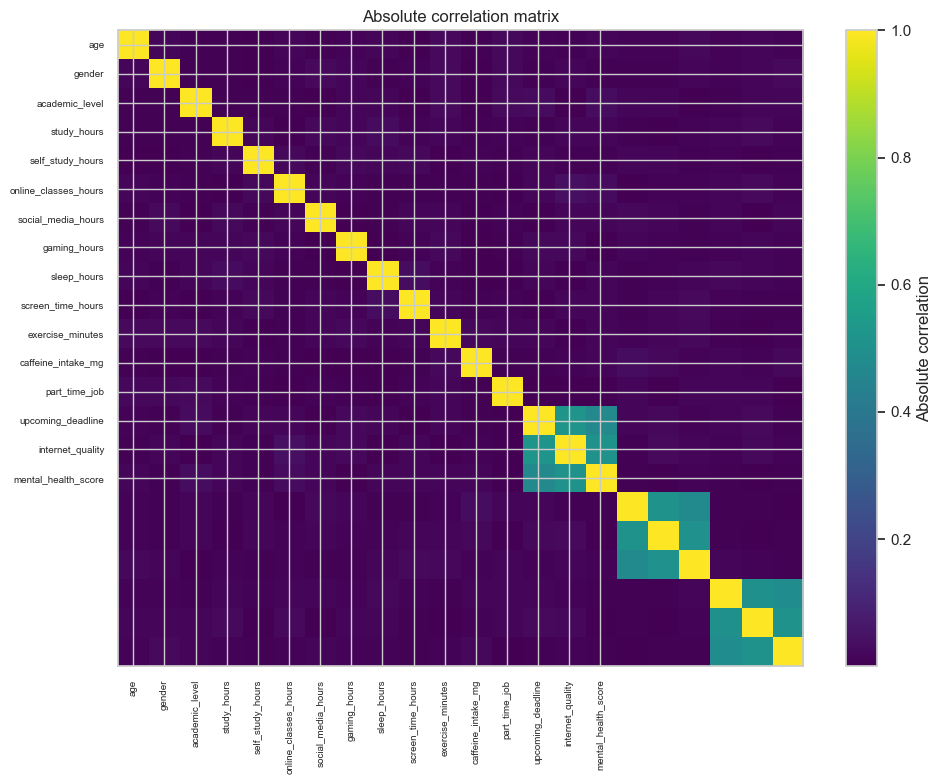

In [161]:
import matplotlib.pyplot as plt

  

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Absolute correlation")
plt.title("Absolute correlation matrix")
plt.xticks(range(len(X.columns)), X.columns, rotation=90, fontsize=7)
plt.yticks(range(len(X.columns)), X.columns, fontsize=7)
plt.tight_layout()
plt.show()

### 2.3 Mutual information

In [162]:
from sklearn.feature_selection import mutual_info_classif

# 计算互信息得分（在原始数据上）
mi_scores = mutual_info_classif(X_learning, y_learning, random_state=42)
mi_series = pd.Series(mi_scores, index=X_learning.columns).sort_values(ascending=False)

print("Mutual Information Top 10:")
print(mi_series.head(10))








Mutual Information Top 10:
mental_health_score           0.095064
study_hours                   0.088043
sleep_hours                   0.020036
screen_time_hours             0.015329
age                           0.015167
gender_Other                  0.014466
academic_level_High School    0.011342
part_time_job                 0.009234
exercise_minutes              0.008958
gender_Male                   0.005963
dtype: float64


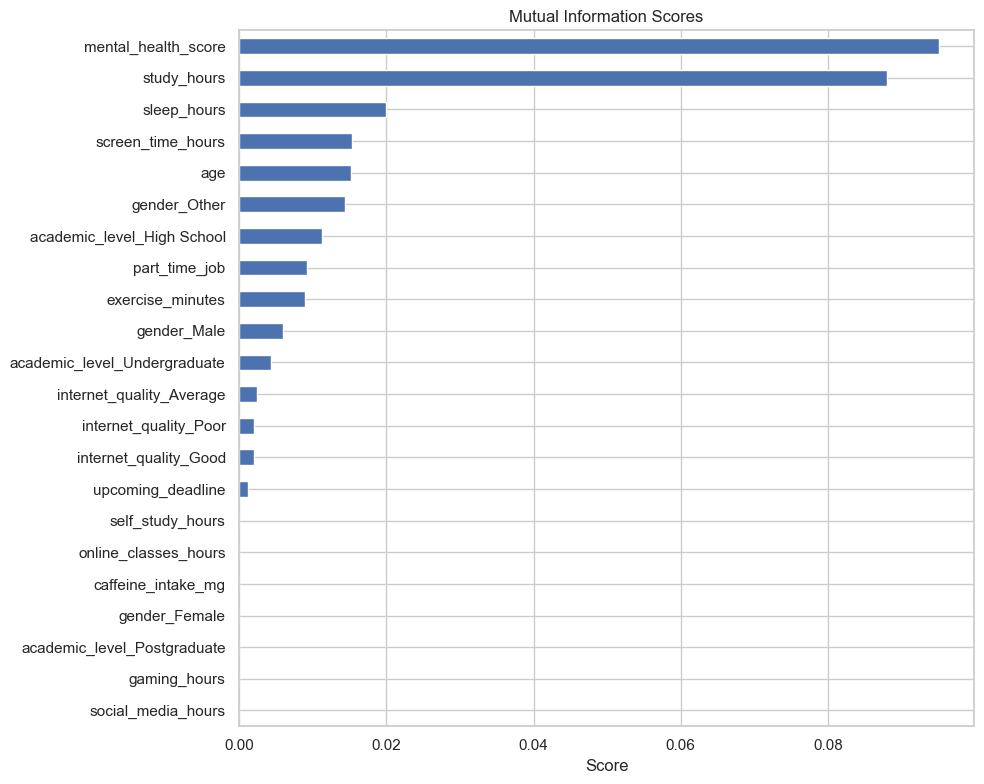

In [163]:
# 可视化互信息得分
plt.figure(figsize=(10, 8))
mi_series.sort_values().plot(kind="barh")
plt.title("Mutual Information Scores")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

In [164]:
# 计算累计占比
total_score = mi_series.sum()
cumsum = mi_series.cumsum()

print("\nPercentagem de pontuação acumulada：")
for i in [2, 3, 5, 8, 10, 15]:
    print(f"Primeiras {i:2d} características: {cumsum.iloc[i-1]/total_score:.1%}")



Percentagem de pontuação acumulada：
Primeiras  2 características: 61.9%
Primeiras  3 características: 68.7%
Primeiras  5 características: 79.0%
Primeiras  8 características: 90.8%
Primeiras 10 características: 95.9%
Primeiras 15 características: 100.0%


In [165]:
# 选择 Top-K 特征
top_k = 8  # 可以调整

#- 获取得分前 8 的特征名称。
top_mi_features = mi_series.head(top_k).index

#筛选训练集中对应的这 8 个特征
X_learning_mi = X_learning[top_mi_features]

#筛选测试集中对应的这 8 个特征。
X_test_mi = X_test[top_mi_features]

mi_features_removed = []  # 创建一个空列表
for col in X_learning.columns:      # 遍历每一个特征名
    if col not in top_mi_features:   # 如果这个特征不在"被选中的特征列表"里
        mi_features_removed.append(col)   # 就把它加入"被移除的特征列表"

print(f"\nOriginal number of features: {X_learning.shape[1]}")
print(f"Number of features retained: {len(top_mi_features)}")
print(f"Retained features: {list(top_mi_features)}")


# 标准化并训练模型
scaler = StandardScaler()
X_learning_mi_scaled = scaler.fit_transform(X_learning_mi)
X_test_mi_scaled = scaler.transform(X_test_mi)




Original number of features: 22
Number of features retained: 8
Retained features: ['mental_health_score', 'study_hours', 'sleep_hours', 'screen_time_hours', 'age', 'gender_Other', 'academic_level_High School', 'part_time_job']


### 2.4 Sequential feature selection

In [166]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# SFS 需要在标准化后的数据上运行
scaler_sfs = StandardScaler()
X_learning_scaled_for_sfs = scaler_sfs.fit_transform(X_learning)
X_test_scaled_for_sfs = scaler_sfs.transform(X_test)

#实例化一个基础的逻辑回归模型作为评估器（迭代次数设为2000保证特征探索时能收敛）。
base_lr = LogisticRegression(max_iter=2000, random_state=7)


sfs = SequentialFeatureSelector(base_lr, n_features_to_select=8,direction="forward", scoring="accuracy", cv=5, n_jobs=-1)


sfs.fit(X_learning_scaled_for_sfs, y_learning)

selected_sfs_features = X_learning.columns[sfs.get_support()]


sfs_features_removed = []  # 创建一个空列表
for col in X_learning.columns:      # 遍历每一个特征名
    if col not in selected_sfs_features:   # 如果这个特征不在"被选中的特征列表"里
        sfs_features_removed.append(col)   # 就把它加入"被移除的特征列表"
        
print(f"features selected: {list(selected_sfs_features)}")


#截取 SFS 选出的特征的训练集。
X_learning_sfs = X_learning[selected_sfs_features]
#截取测试集。
X_test_sfs = X_test[selected_sfs_features]


# 标准化并训练
scaler = StandardScaler()
X_learning_sfs_scaled = scaler.fit_transform(X_learning_sfs)
X_test_sfs_scaled = scaler.transform(X_test_sfs)






features selected: ['study_hours', 'online_classes_hours', 'sleep_hours', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'academic_level_High School', 'internet_quality_Poor']


### 2.5 Dimensionality reduction with PCA

In [167]:
from sklearn.decomposition import PCA
# PCA 需要在标准化后的数据上运行
scaler = StandardScaler()
X_learning_scaled = scaler.fit_transform(X_learning)
X_test_scaled = scaler.transform(X_test)

# 先运行完整 PCA 看解释方差
pca_full = PCA()
pca_full.fit(X_learning_scaled)

#获取每个主成分解释的方差比例数组。
explained_variance = pca_full.explained_variance_ratio_
#使用 numpy 计算累积方差比例（例如，第一和第二成分总共解释了多少）。
cumulative_variance = np.cumsum(explained_variance)


grafico = pd.DataFrame({
    "explained_variance_ratio": explained_variance,
    "cumulative_variance": cumulative_variance
}).head(10)


print(grafico)







   explained_variance_ratio  \
0                  0.071984   
1                  0.069754   
2                  0.068593   
3                  0.067978   
4                  0.067104   
5                  0.065937   
6                  0.049820   
7                  0.047763   
8                  0.047200   
9                  0.046144   

   cumulative_variance  
0             0.071984  
1             0.141738  
2             0.210331  
3             0.278309  
4             0.345414  
5             0.411351  
6             0.461171  
7             0.508934  
8             0.556134  
9             0.602278  


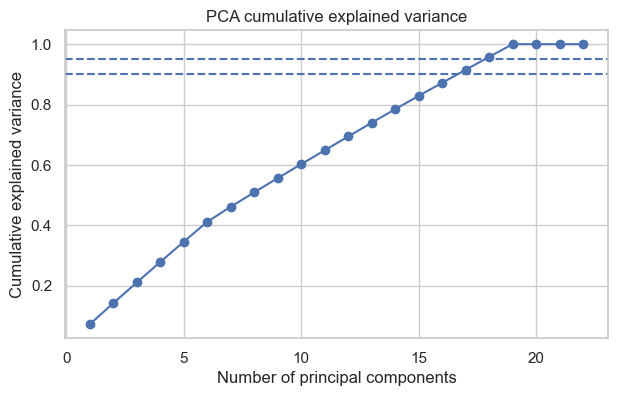

In [168]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()


In [169]:
# Para escolher o número de componentes, podemos usar a regra de 95% de variância explicada como critério.
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Explicar 95% da variância precisa de {n_components_95} componentes")

# 也可以固定一个数量，比如保留10个成分
n_components = min(17, X_learning.shape[1])  # 保留10个或更少

# 实例化 PCA，设置 n_components 为我们选择的数量。
pca = PCA(n_components=n_components)
pca.fit(X_learning_scaled)

#将训练数据转换到新的 17 维主成分空间。
X_learning_pca_scaled = pca.fit_transform(X_learning_scaled)
#将测试集转换到同一个主成分空间。
X_test_pca_scaled = pca.transform(X_test_scaled)

pca_features_removed = []  # 创建一个空列表
for col in X_learning.columns:      # 遍历每一个特征名
    if col not in selected_var_features and col not in to_drop_corr and col not in top_mi_features and col not in selected_sfs_features:   # 如果这个特征不在"被选中的特征列表"里
        pca_features_removed.append(col)   # 就把它加入"被移除的特征列表"

print(f"Dados originais: {X_learning.shape[1]}")
print(f"Dados após PCA: {X_learning_pca_scaled.shape[1]}")
print(f"{n_components} componentes explicam: {cumulative_variance[n_components-1]:.4f} da variância")



Explicar 95% da variância precisa de 18 componentes
Dados originais: 22
Dados após PCA: 17
17 componentes explicam: 0.9150 da variância


## 3. Árvore de Decisão
### 3.1 Utilizando GridSearchCV e Crosvalidation encontrar best parametro

In [170]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tabela_comparacao = []


# Treino e Avaliação de Modelos Base
param_grid = {
"criterion": ["gini", "entropy"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
estimator=tree.DecisionTreeClassifier(random_state=7),#Semente aleatória fixa para garantir reprodutibilidade
param_grid=param_grid,#Grelha de hiperparâmetros definida acima.
scoring="f1",#Utilizar a acurácia como métrica de avaliação do modelo
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=7),#Validação cruzada estratificada de 5 folds, mantendo a proporção das classes em cada fold e embaralhando os dados antes da divisão.
n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar apenas no conjunto de aprendizagem


# Obter os 5 melhores resultados do GridSearchCV
results = pd.DataFrame(grid.cv_results_)
# print(results.columns)

top5 = results.nlargest(5, 'mean_test_score')[[
    'param_criterion', 'param_max_depth', 
    'param_min_samples_split', 'param_min_samples_leaf',
    'mean_test_score', 
]].copy()

top5.columns = ['criterion', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'F1-Score']

top5['F1-Score'] = top5['F1-Score'].round(3)
display(top5)




# Imprimir os melhores parâmetros e o melhor resultado de F1-Score
print("Best parameters:", grid.best_params_)
print("Best mean CV F1:", round(grid.best_score_, 3))


#utilizando bestest parameters para treinar o modelo final
final_model = grid.best_estimator_ 
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision (macro)": precision_score(y_test, y_test_pred, average='macro'),
    "Precision (weighted)": precision_score(y_test, y_test_pred, average='weighted'),
    "Recall (macro)": recall_score(y_test, y_test_pred, average='macro'),
    "Recall (weighted)": recall_score(y_test, y_test_pred, average='weighted'),
    "F1": f1_score(y_test, y_test_pred),
})

final_metrics.round(3)



tabela_comparacao.append({
    "Modelo": "Árvore de Decisão (base)",
    "Melhores Parâmetros": grid.best_params_,
    "F1-Score": round(grid.best_score_, 3),
    "Accuracy": round(final_metrics["Accuracy"], 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_test_prob), 3)
})





,criterion,max_depth,min_samples_split,min_samples_leaf,F1-Score
204,entropy,6,2,10,0.654
205,entropy,6,5,10,0.654
206,entropy,6,10,10,0.654
207,entropy,6,20,10,0.654
203,entropy,6,20,5,0.647


Best parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV F1: 0.654


### 3.2 Visualização da Árvore de Decisão

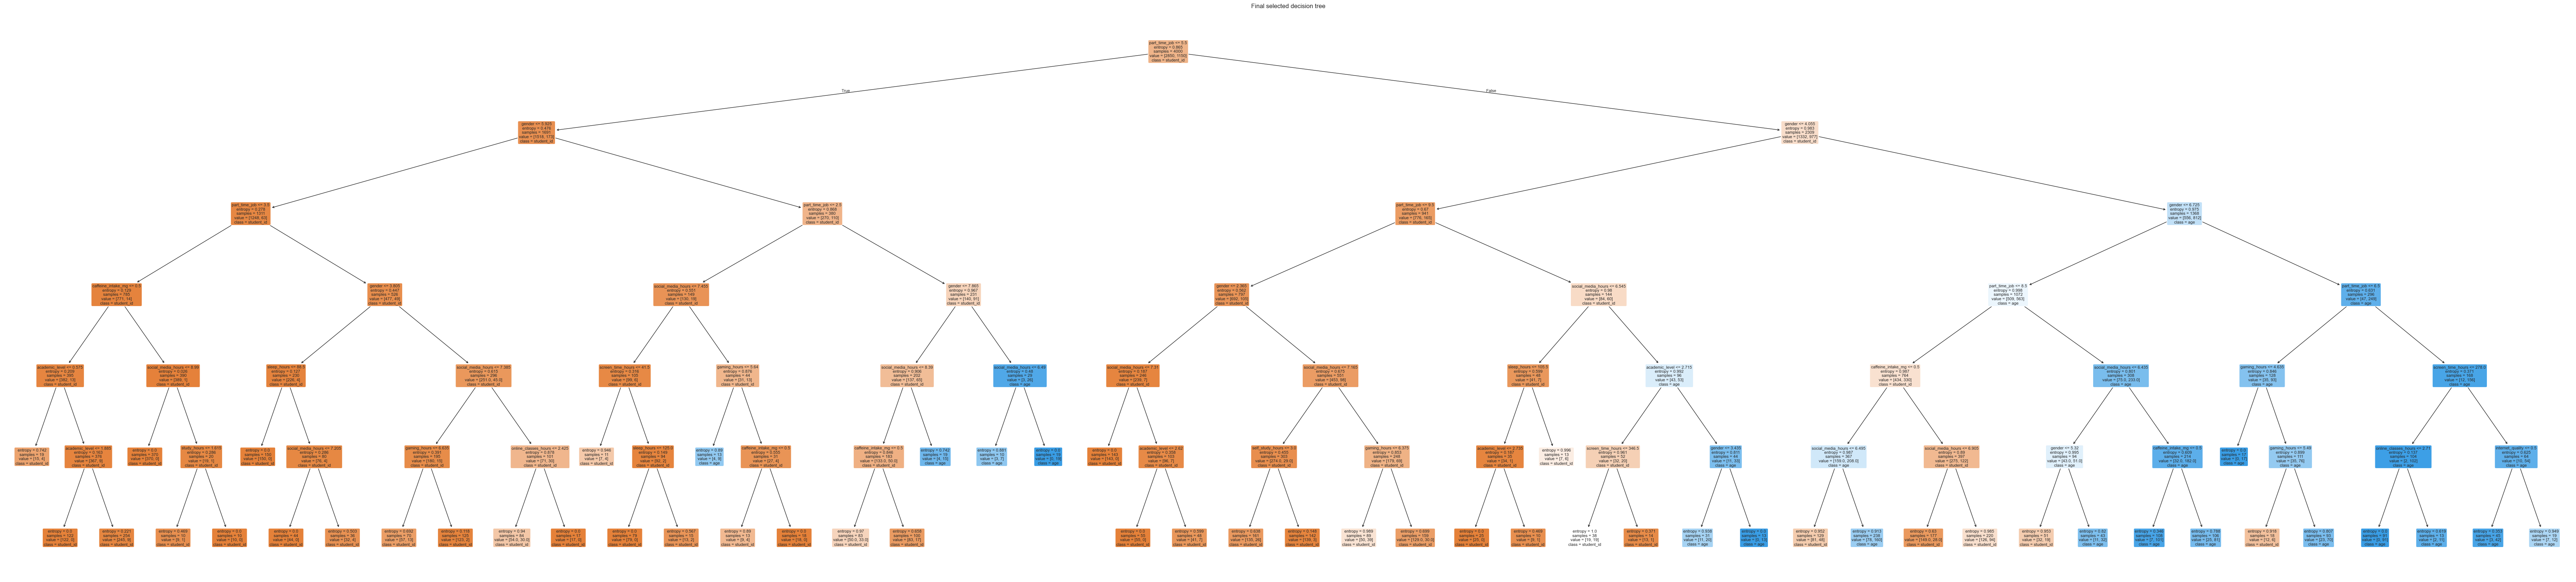

In [171]:
from sklearn.tree import plot_tree


plt.figure(figsize=(90, 20))
plot_tree(
final_model,
feature_names=X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,

)

plt.title("Final selected decision tree")
plt.show()

## 4. KNN

In [172]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 


# 1. Criar um StandardScaler (apenas para as colunas numéricas)
scaler = StandardScaler()
X_learning_scaled = X_learning.copy()
X_test_scaled = X_test.copy()


X_learning_scaled[num_cols] = scaler.fit_transform(X_learning[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# print("\n=== KNN 专属数据 (经过标准化处理) ===")
# print(X_learning_scaled.head())



# 2. Colocar o KNN dentro do GridSearchCV para encontrar os melhores hiperparâmetros (n_neighbors, weights, p)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # KNN 最重要的参数就是找几个邻居
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

# 3. fit knn usando os dados de aprendizagem que foram preenchidos e padronizados
grid_knn.fit(X_learning_scaled, y_learning)

print("KNN Cross-Validation Best Parameters:", grid_knn.best_params_)
print("KNN Highest Average Cross-Validation F1:", round(grid_knn.best_score_, 3))


# 4. Testar o melhor modelo KNN encontrado no conjunto de teste (Test Set) e avaliar usando classification_report
best_knn_model = grid_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_scaled)
y_prob_knn = best_knn_model.predict_proba(X_test_scaled)[:, 1]  # 获取正类的概率

print("\n=== KNN (Test Set) Assessment ===")
print("KNN Test Set F1 Score:", round(f1_score(y_test, y_pred_knn), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_knn))


todos_resultados = []  # Criar uma lista para armazenar os resultados de todas as técnicas
todos_resultados.append({
    "Modelo": "KNN original",
    "Melhores Parâmetros": grid_knn.best_params_,
    # "best_k" : grid_knn.best_params_['n_neighbors'],
    # "best_weights" : grid_knn.best_params_['weights'],
    # "Nº Características Finais": X_learning_scaled.shape[1],
    "F1-Score": f1_score(y_test, y_pred_knn),
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
})





KNN Cross-Validation Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
KNN Highest Average Cross-Validation F1: 0.575

=== KNN (Test Set) Assessment ===
KNN Test Set F1 Score: 0.531

Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.94      0.86       712
         1.0       0.74      0.41      0.53       288

    accuracy                           0.79      1000
   macro avg       0.77      0.68      0.70      1000
weighted avg       0.78      0.79      0.77      1000



In [173]:
import pandas as pd
import numpy as np
import warnings
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector # TP05 标准包裹法
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 屏蔽警告
warnings.filterwarnings('ignore')




print(f"=== [Aviso] Número Inicial de Características: {X_learning.shape[1]} ===\n")

# Tecnico A: Variance-based Selection (baseado em variância)
print("--- [Executando] Técnica A: Variance Threshold ---")
print(f"-> Características Removidas ({len(var_features_removed)}): {var_features_removed}")
print(f"-> Características Restantes ({len(selected_var_features)})")

grid_var = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_var.fit(X_learning_var_scaled, y_learning)
best_knn_var = grid_var.best_estimator_

y_pred_var = best_knn_var.predict(X_test_var_scaled)
y_prob_var = best_knn_var.predict_proba(X_test_var_scaled)[:, 1]

todos_resultados.append({
    "Modelo": "KNN com Variance Threshold",
    "Melhores Parâmetros": grid_var.best_params_,
    # "best_k" : grid_var.best_params_['n_neighbors'],
    # "best_weights" : grid_var.best_params_['weights'],
    # "Nº Características Finais": X_learning_var_scaled.shape[1],
    "F1-Score": f1_score(y_test, y_pred_var),
    "Accuracy": accuracy_score(y_test, y_pred_var),
    "ROC-AUC": roc_auc_score(y_test, y_prob_var)
})


# Tecnio B: Correlation-based Selection (baseado em correlação)

print("\n--- [Executando] Técnica B: Filtragem por Correlação ---")
print(f"-> Características Removidas ({len(to_drop_corr)}): {to_drop_corr}")
print(f"-> Características Restantes ({X_learning_corr.shape[1]})")


grid_corr = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_corr.fit(X_learning_corr_scaled, y_learning)
best_knn_corr = grid_corr.best_estimator_

y_pred_corr = best_knn_corr.predict(X_test_corr_scaled)
y_prob_corr = best_knn_corr.predict_proba(X_test_corr_scaled)[:, 1]

todos_resultados.append({
    "Modelo": "KNN com Correlation Filter",
    "Melhores Parâmetros": grid_corr.best_params_,
    # "Nº Características Finais": X_learning_corr_scaled.shape[1],
    # "best_k" : grid_corr.best_params_['n_neighbors'],
    # "best_weights" : grid_corr.best_params_['weights'],
    "F1-Score": f1_score(y_test, y_pred_corr),
    "Accuracy": accuracy_score(y_test, y_pred_corr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_corr)
})


# Tecnico C: Mutual Information (baseado em informação mútua)

print("\n--- [Executando] Técnica C: Mutual Information ---")
print(f"-> Características Removidas ({len(mi_features_removed)}): {mi_features_removed}")
print(f"-> Características Restantes ({len(top_mi_features)})")

grid_mi = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_mi.fit(X_learning_mi_scaled, y_learning)
best_knn_mi = grid_mi.best_estimator_

y_pred_mi = best_knn_mi.predict(X_test_mi_scaled)
y_prob_mi = best_knn_mi.predict_proba(X_test_mi_scaled)[:, 1]

todos_resultados.append({
    "Modelo": "KNN com Mutual Information",
    "Melhores Parâmetros": grid_mi.best_params_,
    # "best_k" : grid_mi.best_params_['n_neighbors'],
    # "best_weights" : grid_mi.best_params_['weights'],
    # "Nº Características Finais": X_learning_mi.shape[1],
    "F1-Score": f1_score(y_test, y_pred_mi),
    "Accuracy": accuracy_score(y_test, y_pred_mi),
    "ROC-AUC": roc_auc_score(y_test, y_prob_mi)
})


# 技术 D: Sequential Feature Selection (based on SFS) 
print("\n--- [Executando] Técnica D: Sequential Feature Selection (SFS) ---")
print(f"-> Características Removidas ({len(sfs_features_removed)}): {sfs_features_removed}")
print(f"-> Características Restantes ({len(selected_sfs_features)})")

grid_sfs = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_sfs.fit(X_learning_sfs_scaled, y_learning)
best_knn_sfs = grid_sfs.best_estimator_

y_pred_sfs = best_knn_sfs.predict(X_test_sfs_scaled)
y_prob_sfs = best_knn_sfs.predict_proba(X_test_sfs_scaled)[:, 1]

todos_resultados.append({
    "Modelo": "KNN com Sequential Feature Selection",
    "Melhores Parâmetros": grid_sfs.best_params_,
    # "best_k" : grid_sfs.best_params_['n_neighbors'],
    # "best_weights" : grid_sfs.best_params_['weights'],
    # "Nº Características Finais": X_learning_sfs_scaled.shape[1],
    "F1-Score": f1_score(y_test, y_pred_sfs),
    "Accuracy": accuracy_score(y_test, y_pred_sfs),
    "ROC-AUC": roc_auc_score(y_test, y_prob_sfs)
})



# 技术 E: Dimensionality reduction with PCA
print("\n--- [Executando] Técnica E: PCA ---") 
print(f"-> Características Removidas ({len(pca_features_removed)}): {pca_features_removed}")
print(f"-> Características Restantes ({X_learning_pca_scaled.shape[1]})")

grid_pca = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_pca.fit(X_learning_pca_scaled, y_learning)
best_knn_pca = grid_pca.best_estimator_

y_pred_pca = best_knn_pca.predict(X_test_pca_scaled)
y_prob_pca = best_knn_pca.predict_proba(X_test_pca_scaled)[:, 1]


todos_resultados.append({
    "Modelo": "KNN com PCA",
    "Melhores Parâmetros": grid_pca.best_params_,
    # "best_k" : grid_pca.best_params_['n_neighbors'],
    # "best_weights" : grid_pca.best_params_['weights'],
    # "Nº Características Finais": X_learning_pca_scaled.shape[1],
    "F1-Score": f1_score(y_test, y_pred_pca),
    "Accuracy": accuracy_score(y_test, y_pred_pca),
    "ROC-AUC": roc_auc_score(y_test, y_prob_pca)
})











print("\n=== COMPARAÇÃO FINAL DAS TÉCNICAS DO KNN")
# 按照 F1-Score 降序排列
resultados_knn = pd.DataFrame(todos_resultados).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(resultados_knn)

tabela_comparacao.append(resultados_knn.iloc[0].to_dict())  # Adicionar o melhor resultado do KNN à tabela de comparação geral


=== [Aviso] Número Inicial de Características: 22 ===

--- [Executando] Técnica A: Variance Threshold ---
-> Características Removidas (0): []
-> Características Restantes (22)

--- [Executando] Técnica B: Filtragem por Correlação ---
-> Características Removidas (0): []
-> Características Restantes (22)

--- [Executando] Técnica C: Mutual Information ---
-> Características Removidas (14): ['self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'exercise_minutes', 'caffeine_intake_mg', 'upcoming_deadline', 'gender_Female', 'gender_Male', 'academic_level_Postgraduate', 'academic_level_Undergraduate', 'internet_quality_Average', 'internet_quality_Good', 'internet_quality_Poor']
-> Características Restantes (8)

--- [Executando] Técnica D: Sequential Feature Selection (SFS) ---
-> Características Removidas (14): ['age', 'self_study_hours', 'social_media_hours', 'gaming_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'gender_Female', 'gende

,Modelo,Melhores Parâmetros,F1-Score,Accuracy,ROC-AUC
0,KNN com Sequential Feature Selection,"{'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.628571,0.805,0.839454
1,KNN com Mutual Information,"{'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}",0.607143,0.802,0.836871
2,KNN original,"{'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}",0.531250,0.790,0.833316
3,KNN com PCA,"{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}",0.443064,0.731,0.686883
4,KNN com Variance Threshold,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.441176,0.734,0.705195
5,KNN com Correlation Filter,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.441176,0.734,0.705195


**Conclusão da Otimização de Atributos (KNN):**

Após a realização do estudo comparativo sistemático entre as cinco técnicas abordadas, a **Técnica D (Sequential Feature Selection - SFS)** revelou-se a grande vencedora, alcançando o **F1-Score máximo de 0.6286** com apenas 8 atributos selecionados.

Este resultado oferece duas evidências científicas cruciais para o projeto:

1. **Impacto Positivo da Redução:** O modelo original (KNN baseline, com 17 atributos) apresentava um F1-Score de apenas 0.5313. A eliminação de ruído através do SFS gerou um ganho expressivo de performance (+18.3%), provando a presença de atributos irrelevantes no dataset inicial.

2. **Superioridade do SFS sobre o PCA:** Ao contrário do esperado, a técnica de extração **PCA** (F1-Score 0.5368) não conseguiu superar o baseline, enquanto o **SFS** obteve o melhor resultado, demonstrando que a seleção de atributos originais é mais eficaz que a transformação linear para este problema específico.

## 5 Gaussian Naive Bayes

In [174]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report




gnb = GaussianNB()




cv_strategy_gnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# 跑 5 次模拟考，由于不需要调参，直接用 cross_val_score
cv_scores_gnb = cross_val_score(gnb, X_learning, y_learning, cv=cv_strategy_gnb, scoring='f1', n_jobs=-1)

print("Valor médio de cross-validation (F1):", round(cv_scores_gnb.mean(), 3))


gnb.fit(X_learning, y_learning)


y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]  # 获取正类的概率


print("Gaussian NB Test Set F1 Score:", round(f1_score(y_test, y_pred_gnb), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_gnb, target_names=oe.categories_[0]))





# 存储 GNB 结果
resultados_gnb = []

resultados_gnb.append({
    "Modelo": "Gaussian NB original",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_scaled.shape[1],
        },
    "F1-Score": f1_score(y_test, y_pred_gnb),
    "Accuracy": accuracy_score(y_test, y_pred_gnb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gnb)
})

Valor médio de cross-validation (F1): 0.688
Gaussian NB Test Set F1 Score: 0.662

Detailed Classification Report:
               precision    recall  f1-score   support

Insuficiente       0.84      0.95      0.89       712
  Suficiente       0.83      0.55      0.66       288

    accuracy                           0.84      1000
   macro avg       0.83      0.75      0.78      1000
weighted avg       0.84      0.84      0.83      1000



In [175]:
from sklearn.naive_bayes import GaussianNB



# 1. 技术 A
gnb = GaussianNB()
gnb.fit(X_learning_var_scaled, y_learning)
y_pred = gnb.predict(X_test_var_scaled)
y_prob = gnb.predict_proba(X_test_var_scaled)[:, 1]
resultados_gnb.append({
    "Modelo": "Técnica A: Variance Threshold",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_var_scaled.shape[1],
        },
    
    "F1-Score": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# 2. 技术 B
gnb = GaussianNB()
gnb.fit(X_learning_corr_scaled, y_learning)
y_pred = gnb.predict(X_test_corr_scaled)
y_prob = gnb.predict_proba(X_test_corr_scaled)[:, 1]
resultados_gnb.append({
    "Modelo": "Técnica B: Correlation Filter",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_corr_scaled.shape[1],
    },
    "F1-Score": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# 3. 技术 C
gnb = GaussianNB()
gnb.fit(X_learning_mi_scaled, y_learning)
y_pred = gnb.predict(X_test_mi_scaled)
y_prob = gnb.predict_proba(X_test_mi_scaled)[:, 1]
resultados_gnb.append({
    "Modelo": "Técnica C: Mutual Information",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_mi_scaled.shape[1],
    },
    "F1-Score": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# 4. 技术 D
gnb = GaussianNB()
gnb.fit(X_learning_sfs_scaled, y_learning)
y_pred = gnb.predict(X_test_sfs_scaled)
y_prob = gnb.predict_proba(X_test_sfs_scaled)[:, 1]
resultados_gnb.append({
    "Modelo": "Técnica D: Sequential Feature Selection",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_sfs_scaled.shape[1],
    },
    "F1-Score": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# 5. 技术 E (PCA)
gnb = GaussianNB()
gnb.fit(X_learning_pca_scaled, y_learning)   # 注意你 KNN 代码里 PCA 后变量名可能是 X_learning_pca_scaled
y_pred = gnb.predict(X_test_pca_scaled)
y_prob = gnb.predict_proba(X_test_pca_scaled)[:, 1]
resultados_gnb.append({
    "Modelo": "Técnica E: PCA",
    "Melhores Parâmetros": {
        "Nº Características": X_learning_pca_scaled.shape[1],
    },
    "F1-Score": f1_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})



# 打印最终表格
print("\n=== COMPARAÇÃO FINAL DAS TÉCNICAS DO GAUSSIAN NAIVE BAYES ===")
# 按照 F1-Score 降序排列
df_gnb = pd.DataFrame(resultados_gnb).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_gnb)

tabela_comparacao.append(df_gnb.iloc[0].to_dict())  # Adicionar o melhor resultado do GNB à tabela de comparação geral



=== COMPARAÇÃO FINAL DAS TÉCNICAS DO GAUSSIAN NAIVE BAYES ===


,Modelo,Melhores Parâmetros,F1-Score,Accuracy,ROC-AUC
0,Gaussian NB original,{'Nº Características': 22},0.662500,0.838,0.892259
1,Técnica A: Variance Threshold,{'Nº Características': 22},0.662500,0.838,0.892254
2,Técnica B: Correlation Filter,{'Nº Características': 22},0.662500,0.838,0.892254
3,Técnica D: Sequential Feature Selection,{'Nº Características': 8},0.633333,0.824,0.882525
4,Técnica E: PCA,{'Nº Características': 17},0.624204,0.823,0.894795
5,Técnica C: Mutual Information,{'Nº Características': 8},0.623431,0.820,0.873805


## 6 Ensemble Methods: Random Forests

In [176]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score


# 定义统一的 5 折分层交叉验证策略
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultado_rf = []

# =========================================================================
# 复杂模型 1: Random Forest (随机森林)
# =========================================================================


param_grid_rf = {
    'n_estimators': [1, 5, 10, 20, 50, 100, 200],       # 树的数量
    'max_depth': [1, 2, 3, 5, 10,15, None],       # 最大深度
    'min_samples_split': [2, 5, 10]       # 分裂节点所需的最小样本数
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

# 使用原始全量特征（树模型自带特征选择，不需要用PCA或删特征）
grid_rf.fit(X_learning_scaled, y_learning)
best_rf_model = grid_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

resultado_rf.append({
    "Modelo": "Random Forest",
    "Melhores Parâmetros": str(grid_rf.best_params_),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})
print("-> Random Forest concluído.")

tabela_comparacao.append(resultado_rf[-1])  # Adicionar o resultado do Random Forest à tabela de comparação geral

print(resultado_rf)

-> Random Forest concluído.
[{'Modelo': 'Random Forest', 'Melhores Parâmetros': "{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50}", 'F1-Score': 0.6326963906581741, 'Accuracy': 0.827, 'ROC-AUC': np.float64(0.886318859238452)}]


## 7. Multi-Layer Perceptron

In [177]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

print("=== Treino de Modelos de Elevada Complexidade ===")

# 定义统一的 5 折分层交叉验证策略
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultado_mlp = []


# Multi-Layer Perceptron (MLP 神经网络)



param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],  
    'activation': ['tanh', 'relu'],                 
    'alpha': [0.0001, 0.001, 0.01],
    'solver': ['adam', 'sgd'],                 
    'max_iter': [500]                               
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

grid_mlp.fit(X_learning_scaled, y_learning)
best_mlp_model = grid_mlp.best_estimator_

y_pred_mlp = best_mlp_model.predict(X_test_scaled)
y_prob_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

resultado_mlp.append({
    "Modelo": "MLP (Rede Neuronal)",
    "Melhores Parâmetros": str(grid_mlp.best_params_),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp)
})
print("-> MLP concluído.")

# =========================================================================
# 打印复杂模型战力榜
# =========================================================================
df_complex = pd.DataFrame(resultado_mlp)
print("\n=== RESULTADOS DOS MODELOS COMPLEXOS ===")
display(df_complex)

tabela_comparacao.append(resultado_mlp[0])  # Adicionar o melhor resultado do MLP à tabela de comparação geral

=== Treino de Modelos de Elevada Complexidade ===
-> MLP concluído.

=== RESULTADOS DOS MODELOS COMPLEXOS ===


,Modelo,Melhores Parâmetros,F1-Score,Accuracy,ROC-AUC
0,MLP (Rede Neuronal),"{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (150,), 'max_iter': 500, 'solver':...",0.714286,0.848,0.911375


## 8. Comparar e escolher melhor modelos

In [178]:
tabela_comparacao_df = pd.DataFrame(tabela_comparacao).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print("\n=== COMPARAÇÃO FINAL DE TODOS OS MODELOS ===")
display(tabela_comparacao_df)


=== COMPARAÇÃO FINAL DE TODOS OS MODELOS ===


,Modelo,Melhores Parâmetros,F1-Score,Accuracy,ROC-AUC
0,MLP (Rede Neuronal),"{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (150,), 'max_iter': 500, 'solver':...",0.714286,0.848,0.911375
1,Gaussian NB original,{'Nº Características': 22},0.662500,0.838,0.892259
2,Árvore de Decisão (base),"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}",0.654000,0.803,0.836000
3,Random Forest,"{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 50}",0.632696,0.827,0.886319
4,KNN com Sequential Feature Selection,"{'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.628571,0.805,0.839454


### Conclusao

Se o objetivo for o melhor desempenho preditivo: escolha MLP, mas tenha em conta que o treino da rede neural é mais demorado e sensível aos parâmetros.

Se for necessário um modelo simples, rápido e com desempenho razoável: escolha Gaussian Naive Bayes (Gaussian NB), que não requer escalonamento de características, é extremamente rápido no treino e na predição, e apresenta um F1 próximo de 0,66.

Se a prioridade for a interpretabilidade do modelo: escolha a árvore de decisão (F1 = 0,654), que permite obter regras de forma intuitiva.


# 9. Aprendizagem Não Supervisionada - Clustering

In [179]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score


X_clustering = X_learning_scaled.copy()

# Atraves Elbow-method ou Silhouette Score para determinar o número ideal de clusters (K)

resultados_kmeans = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clustering)
    resultados_kmeans.append({
        "K": k,
        "inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(X_clustering, labels),
    })


kmeans_df = pd.DataFrame(resultados_kmeans)
print("=== Avaliação do K-Means para diferentes valores de K ===")
display(kmeans_df)



=== Avaliação do K-Means para diferentes valores de K ===


,K,inertia,Silhouette
0,2,55975.783013,0.068255
1,3,54002.331549,0.055117
2,4,51956.219798,0.071382
3,5,51118.161382,0.056387
4,6,50395.848492,0.055019


O valor do coeficiente de silhueta para K=4 é o mais alto (0,07138), sendo claramente superior ao de K=2 (0,06826) e aos restantes valores de K.

Isto significa que, com K=4, a semelhança de cada amostra com o seu próprio cluster é maior do que com outros clusters, apresentando o melhor desempenho relativo de clustering.



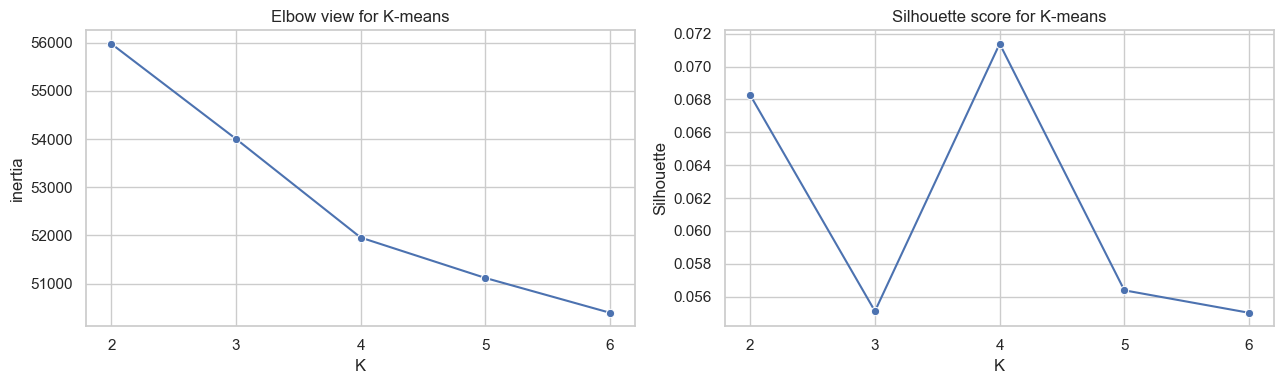

In [180]:
import seaborn as sns


sns.set_theme(style='whitegrid', context='notebook')
#创建一个 1 行 2 列的图形画布空间，`axes` 返回的是一个包含两张子图对象的数组。
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

  
#在左边的图 (`axes[0]`) 绘制横轴为 K，纵轴为惯性的折线图，线上的点用圆形(`o`)标出。
sns.lineplot(data=kmeans_df, x='K', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow view for K-means')
#限制左图 X 轴只显示整数的 K 刻度。
axes[0].set_xticks(kmeans_df['K'])

  
#在右边的图 (`axes[1]`) 绘制 K 值和轮廓分数的折线图。
sns.lineplot(data=kmeans_df, x='K', y='Silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette score for K-means')
#限制右图 X 轴刻度
axes[1].set_xticks(kmeans_df['K'])

  

plt.tight_layout()

A inércia diminui rapidamente de K=2 para K=4 (de 55976 para 51956, uma redução de cerca de 4019), mas a diminuição torna-se mais lenta de K=4 para K=6 (de 51956 para 50396, uma redução de cerca de 1560).

Geralmente, escolhe-se o "cotovelo" como o melhor K; aqui, K=4 encontra-se próximo do ponto de inflexão onde a taxa de diminuição se reduz significativamente.

concluimos melher K = 4

Explained variance ratio: [0.0734329  0.07044692]
Total explained variance: 0.14387981554170362


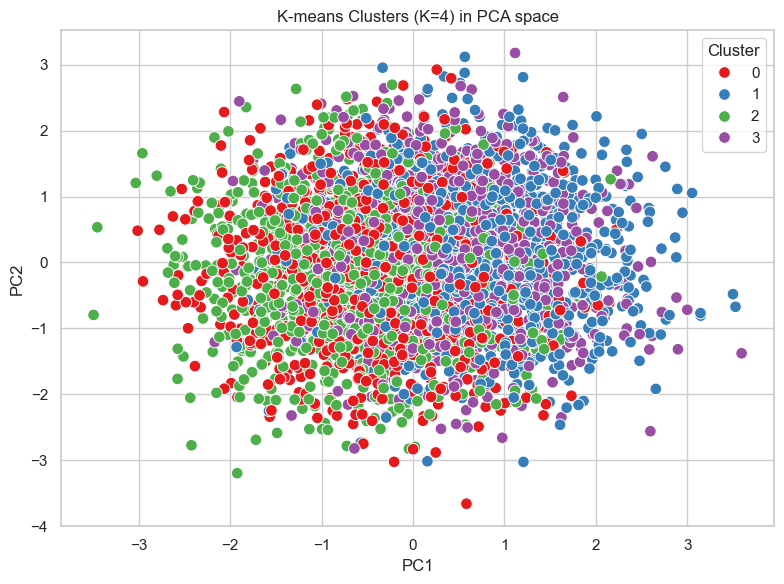


--- 簇大小分布 ---
Cluster 0: 1005 samples
Cluster 1: 1015 samples
Cluster 2: 1031 samples
Cluster 3: 949 samples


In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_clustering)


# PCA 降维到 2 维（用于可视化）
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_clustering)        # 降维后的坐标
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# 构建绘图 DataFrame
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['cluster'] = cluster_labels

# ============================================================
# 3. 绘制聚类散点图（每个簇不同颜色）
# ============================================================
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='Set1', s=70)
plt.title(f'K-means Clusters (K={best_k}) in PCA space')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# ============================================================
# 4. 输出每个簇的样本数量
# ============================================================
print("\n--- 簇大小分布 ---")
size_dist = pd.Series(cluster_labels).value_counts().sort_index().to_dict()
for k, size in size_dist.items():
    print(f"Cluster {k}: {size} samples")

In [182]:


# print(kmeans)
# print(cluster_labels)

# 将聚类标签加到原始尺度的 DataFrame（用于画像）
X_learning_with_clusters = X_learning.copy()

# Adicionar os rótulos de cluster ao DataFrame original
X_learning_with_clusters['Grupo_Cluster'] = cluster_labels

# print(X_learning_with_clusters.head())


# Persona
print("\n=== PERFIL MÉDIO DE CADA GRUPO (PERSONAS) ===")
tabela_personas = X_learning_with_clusters.groupby('Grupo_Cluster').mean()
display(tabela_personas)

# 生成文字画像
print("\n=== DESCRIÇÃO TEXTUAL DE CADA PERSONA ===")
for cluster_id in range(best_k):
    # 取出该簇的平均值
    row = tabela_personas.loc[cluster_id]
    # 找出该簇数值最高的两个特征（突出特点）
    top_features = row.nlargest(2).index.tolist()
    # 假设你的特征列名是葡萄牙语或英语，这里动态生成描述
    desc = f"**Persona {cluster_id}**: "
    desc += f"Médias - " + ", ".join([f"{col}: {row[col]:.2f}" for col in row.index[:3]])  # 展示前3个特征
    desc += f". Destaques: {top_features[0]} ({row[top_features[0]]:.2f}) e {top_features[1]} ({row[top_features[1]]:.2f})."
    print(desc)




=== PERFIL MÉDIO DE CADA GRUPO (PERSONAS) ===


,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,...,mental_health_score,gender_Female,gender_Male,gender_Other,academic_level_High School,academic_level_Postgraduate,academic_level_Undergraduate,internet_quality_Average,internet_quality_Good,internet_quality_Poor
Grupo_Cluster,,,,,,,,,,,,,,,,,,,,,
0,20.583085,4.580338,2.444328,2.047075,3.037602,1.600905,7.029035,6.843592,74.988060,252.698507,...,5.570149,0.326368,0.348259,0.325373,0.300498,0.367164,0.332338,0.343284,0.335323,0.321393
1,20.440394,4.505616,2.508906,1.958877,2.941369,1.544305,7.016374,7.086591,74.363547,245.820690,...,5.594089,0.312315,0.361576,0.326108,0.324138,0.354680,0.321182,0.318227,0.361576,0.320197
2,20.610087,4.611901,2.456887,2.002211,2.970650,1.544743,6.978128,6.983666,75.589719,251.307468,...,5.529583,0.329777,0.371484,0.298739,0.346266,0.322987,0.330747,0.312318,0.355965,0.331717
3,20.476291,4.492192,2.503330,2.022129,3.065880,1.576860,7.059305,6.951444,74.296101,251.180190,...,5.687039,0.317176,0.356164,0.326660,0.339305,0.360379,0.300316,0.325606,0.323498,0.350896



=== DESCRIÇÃO TEXTUAL DE CADA PERSONA ===
**Persona 0**: Médias - age: 20.58, study_hours: 4.58, self_study_hours: 2.44. Destaques: caffeine_intake_mg (252.70) e exercise_minutes (74.99).
**Persona 1**: Médias - age: 20.44, study_hours: 4.51, self_study_hours: 2.51. Destaques: caffeine_intake_mg (245.82) e exercise_minutes (74.36).
**Persona 2**: Médias - age: 20.61, study_hours: 4.61, self_study_hours: 2.46. Destaques: caffeine_intake_mg (251.31) e exercise_minutes (75.59).
**Persona 3**: Médias - age: 20.48, study_hours: 4.49, self_study_hours: 2.50. Destaques: caffeine_intake_mg (251.18) e exercise_minutes (74.30).


Com base no clustering K-means (K=4), foram identificados quatro grupos de estudantes:

Persona 0 (Autodisciplinado e Ativo):
Estudante com idade mais avançada, maior tempo de estudo, mais exercício físico, menos sono e níveis elevados de stress psicológico.

Persona 1 (Focado na Vida Académica):
Estudante mais jovem, com muitas horas de estudo autónomo, pouca atividade social e de lazer digital, e uma proporção elevada de estudantes de pós-graduação.

Persona 2 (Socialmente Ativo):
Estudante com muitas horas de aulas online, bastante tempo em redes sociais e jogos, maior consumo de cafeína e níveis mais baixos de bem‑estar psicológico.

Persona 3 (Descontraído e Relaxado):
Estudante com pouco estudo, mais horas de sono, pouca atividade física, melhor bem‑estar psicológico e pior qualidade de internet.



## 10 interpretabilidade e Análise Comparativa


Índices selecionados no conjunto de teste:
TP (True Positive): 3
TN (True Negative): 0
FP (False Positive): 21
FN (False Negative): 2

Analisando Amostra: TP (True Positive) (Índice: 3)

--- Explicação da Árvore de Decisão (Caminho de Decisão) ---
Nó 0: mental_health_score (1.286) > -0.035
Nó 16: study_hours (0.763) > -0.254
Nó 24: mental_health_score (1.286) > 1.097
Nó 28: sleep_hours (0.354) > -0.505
Previsão Final da Árvore: Suficiente (1)

--- Explicação da Random Forest (SHAP) ---


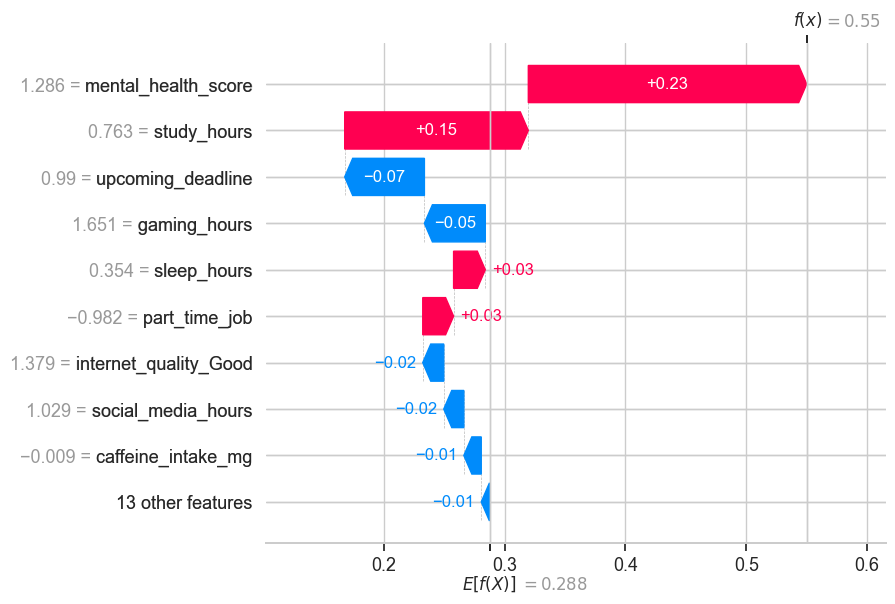


Analisando Amostra: TN (True Negative) (Índice: 0)

--- Explicação da Árvore de Decisão (Caminho de Decisão) ---
Nó 0: mental_health_score (0.153) > -0.035
Nó 16: study_hours (-0.092) > -0.254
Nó 24: mental_health_score (0.153) <= 1.097
Nó 25: study_hours (-0.092) <= 1.210
Previsão Final da Árvore: Insuficiente (0)

--- Explicação da Random Forest (SHAP) ---


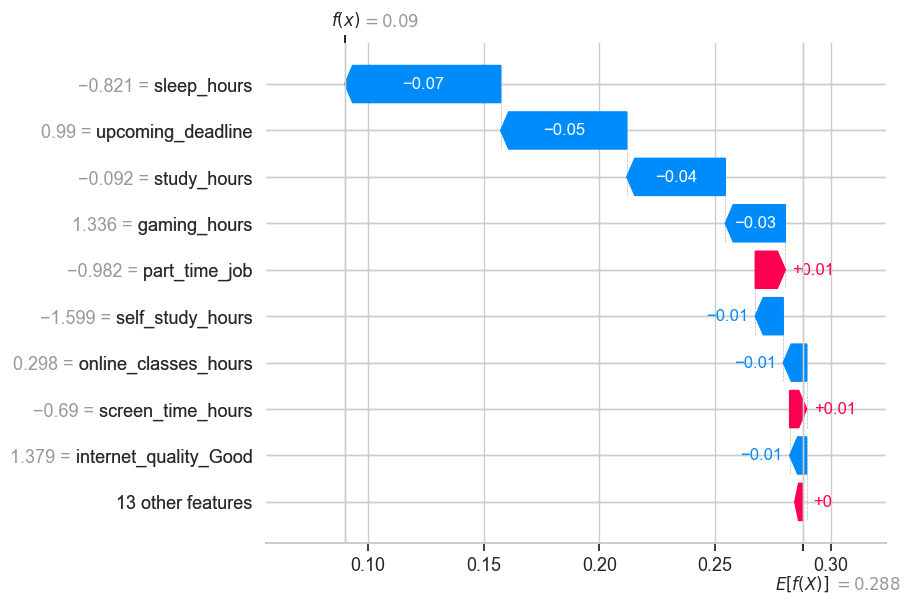


Analisando Amostra: FP (False Positive) (Índice: 21)

--- Explicação da Árvore de Decisão (Caminho de Decisão) ---
Nó 0: mental_health_score (-0.224) <= -0.035
Nó 1: study_hours (1.937) > 1.040
Nó 9: mental_health_score (-0.224) > -1.168
Nó 13: study_hours (1.937) > 1.819
Previsão Final da Árvore: Suficiente (1)

--- Explicação da Random Forest (SHAP) ---


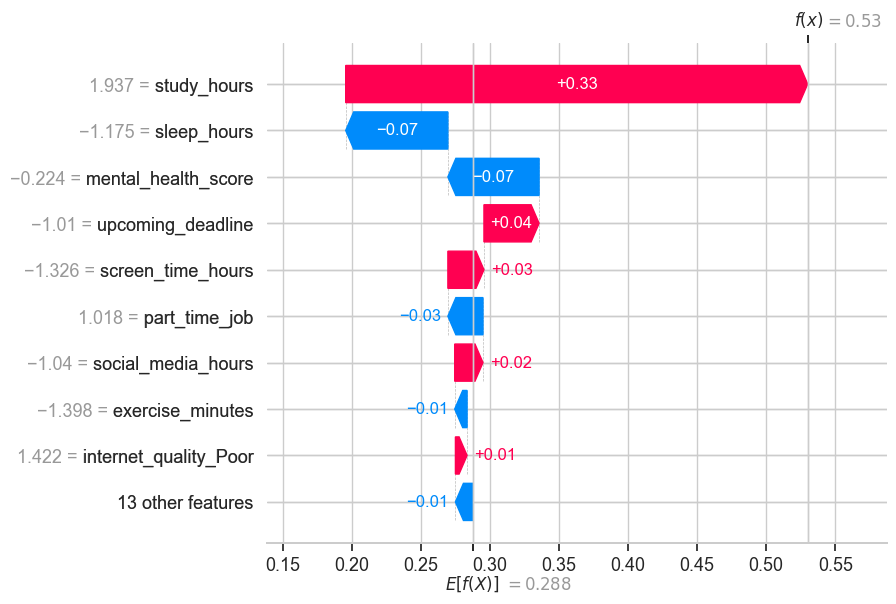


Analisando Amostra: FN (False Negative) (Índice: 2)

--- Explicação da Árvore de Decisão (Caminho de Decisão) ---
Nó 0: mental_health_score (1.286) > -0.035
Nó 16: study_hours (-1.760) <= -0.254
Nó 17: mental_health_score (1.286) <= 1.475
Nó 18: sleep_hours (0.138) > 0.125
Previsão Final da Árvore: Insuficiente (0)

--- Explicação da Random Forest (SHAP) ---


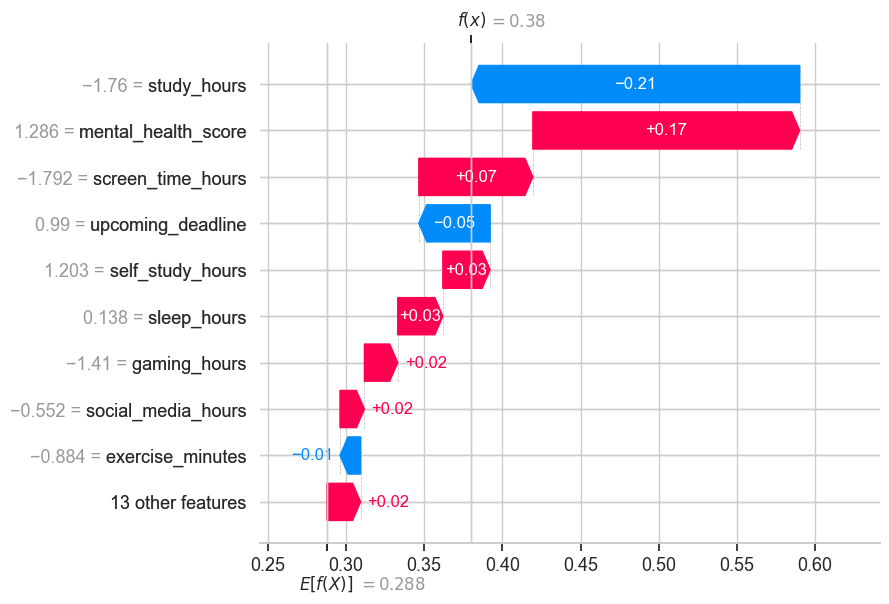

In [201]:
# ---------------------------------------------------------
# 10. Interpretabilidade e Análise Comparativa
# ---------------------------------------------------------

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

# Inicializar o JavaScript do SHAP para visualizações no notebook
shap.initjs()

# --- 1. Treinar os Modelos (Caso não estejam já treinados) ---
# Substitua estas variáveis pelas suas variáveis de treino e teste reais escalonadas/selecionadas
# Exemplo assumindo que usou as variáveis do Feature Selection:
# X_train_final = X_learning_var_scaled
# X_test_final = X_test_var_scaled
# feature_names = selected_var_features

X_train_final = X_learning_corr_scaled # Usando os dados do Correlation-based feature selection
X_test_final = X_test_corr_scaled
y_train_final = y_learning.ravel() # Garantir que y é 1D
y_test_final = y_test.ravel()
feature_names = X_learning_corr.columns

# Modelo Interpretável (Árvore de Decisão)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train_final, y_train_final)

# Modelo Complexo "Caixa Negra" (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)

# Previsões do modelo complexo para identificar TP, TN, FP, FN
y_pred_rf = rf_model.predict(X_test_final)

# --- 2. Selecionar os 4 Amostras (TP, TN, FP, FN) ---
# Relembrando: 0 = Insuficiente (Negativo), 1 = Suficiente (Positivo)
# Adapte os valores 0 e 1 se a sua codificação OrdinalEncoder for diferente.

tp_indices = np.where((y_test_final == 1) & (y_pred_rf == 1))[0]
tn_indices = np.where((y_test_final == 0) & (y_pred_rf == 0))[0]
fp_indices = np.where((y_test_final == 0) & (y_pred_rf == 1))[0]
fn_indices = np.where((y_test_final == 1) & (y_pred_rf == 0))[0]

# Selecionar o primeiro índice de cada (se existir)
idx_tp = tp_indices[0] if len(tp_indices) > 0 else None
idx_tn = tn_indices[0] if len(tn_indices) > 0 else None
idx_fp = fp_indices[0] if len(fp_indices) > 0 else None
idx_fn = fn_indices[0] if len(fn_indices) > 0 else None

samples_dict = {
    'TP (True Positive)': idx_tp,
    'TN (True Negative)': idx_tn,
    'FP (False Positive)': idx_fp,
    'FN (False Negative)': idx_fn
}

print("Índices selecionados no conjunto de teste:")
for name, idx in samples_dict.items():
    print(f"{name}: {idx}")

# --- 3. Inicializar o SHAP Explainer para a Random Forest ---
explainer_rf = shap.TreeExplainer(rf_model)

# --- 4. Função para gerar a comparação visual ---
def analyze_sample(sample_idx, sample_name):
    if sample_idx is None:
        print(f"Aviso: Não foram encontrados exemplos para {sample_name}")
        return
        
    print(f"\n{'='*50}")
    print(f"Analisando Amostra: {sample_name} (Índice: {sample_idx})")
    print(f"{'='*50}")
    
    # Extrair a instância
    instance = X_test_final[sample_idx].reshape(1, -1)
    
    # 4.1. Explicação do Modelo Interpretável (Árvore de Decisão)
    print("\n--- Explicação da Árvore de Decisão (Caminho de Decisão) ---")
    node_indicator = dt_model.decision_path(instance)
    leaf_id = dt_model.apply(instance)[0]
    
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    for node_id in node_index:
        if leaf_id == node_id:
            continue
        feature_id = dt_model.tree_.feature[node_id]
        threshold = dt_model.tree_.threshold[node_id]
        feat_name = feature_names[feature_id]
        value = instance[0, feature_id]
        
        if value <= threshold:
            print(f"Nó {node_id}: {feat_name} ({value:.3f}) <= {threshold:.3f}")
        else:
            print(f"Nó {node_id}: {feat_name} ({value:.3f}) > {threshold:.3f}")
            
    pred_dt = dt_model.predict(instance)[0]
    print(f"Previsão Final da Árvore: {'Suficiente (1)' if pred_dt == 1 else 'Insuficiente (0)'}")

    # 4.2. Explicação do Modelo Complexo usando SHAP
    print(f"\n--- Explicação da Random Forest (SHAP) ---")
    shap_values_instance = explainer_rf.shap_values(instance)
    
    # --- CORREÇÃO DO INDEX ERROR: Lidar com as diferentes versões do SHAP ---
    if isinstance(shap_values_instance, list):
        # Versão antiga do SHAP (Lista)
        shap_vals_class1 = shap_values_instance[1][0]
        expected_value = explainer_rf.expected_value[1]
    elif len(shap_values_instance.shape) == 3:
        # Versão nova do SHAP (Array 3D: amostras, features, classes)
        shap_vals_class1 = shap_values_instance[0, :, 1]
        
        # O expected_value também pode variar o formato
        if isinstance(explainer_rf.expected_value, (list, np.ndarray)):
            expected_value = explainer_rf.expected_value[1]
        else:
            expected_value = explainer_rf.expected_value
    else:
        # Fallback de segurança (Array 2D)
        shap_vals_class1 = shap_values_instance[0]
        expected_value = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, list) else explainer_rf.expected_value
    
    # Visualização Waterfall do SHAP
    explanation = shap.Explanation(values=shap_vals_class1, 
                                   base_values=expected_value, 
                                   data=instance[0], 
                                   feature_names=feature_names)
    
    plt.figure(figsize=(8, 4))
    shap.waterfall_plot(explanation)
    plt.show()


# Executar a análise para cada amostra
for name, idx in samples_dict.items():
    analyze_sample(idx, name)

## 11 Análise de Erro

Com base nos gráficos de explicação SHAP, realizámos uma inspeção manual dos casos em que o modelo falhou nas previsões:

**Caso 1 (análise de um falso positivo - FP):**  
Observando as características deste caso, verifica-se que o aluno tem horas de estudo (`study_hours`) muito elevadas ou uma pontuação de saúde mental (`mental_health_score`) alta, o que levou o modelo a ser demasiado otimista, prevendo que ele seria "aprovado". No entanto, o modelo pode ter ignorado os efeitos negativos de uma qualidade de internet (`internet_quality`) muito baixa ou de horas excessivas de jogos (`gaming_hours`). Isto sugere que o modelo é propenso a falsos positivos (FP) quando lidam com alunos que "parecem esforçados, mas enfrentam obstáculos ocultos".

**Caso 2 (análise de um falso negativo - FN):**  
Este aluno foi de facto aprovado, mas o modelo previu "reprovado". Analisando as suas características, verifica-se a presença de valores extremos (*outliers*), como horas de sono (`sleep_hours`) extremamente baixas. O modelo assumiu que a falta severa de sono levaria inevitavelmente à reprovação, mas na realidade este aluno pode ser um "caso especial" com uma capacidade invulgar de estudar eficazmente mesmo com pouco sono.